# Modelo Finbert
A continuación, mostramos el procedimiento realizado para evaluar las técnicas de *Zero-shot* y *Few Shot* para el conjunto de datos **Financial Phrase Bank** utilizando el modelo FinBert.

In [1]:
!pip install -q transformers accelerate bitsandbytes datasets scikit-learn torch huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 11.8 MB/s eta 0:00:00


In [4]:
import torch
import numpy as np
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, BertForMaskedLM
from sklearn.metrics import f1_score, classification_report
from tqdm import tqdm
from huggingface_hub import login
from google.colab import userdata
import pandas as pd


hf_token = userdata.get('hf_token')
login(token=hf_token)

# Aplicamos el modelo en GPU
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Usando GPU CUDA (Google Colab)")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Usando GPU MPS (Mac Pro M5)")
else:
    device = torch.device("cpu")
    print("Usando CPU")

# Cargamos el conjuto de datos Financial PhraseBank
print("\nCargando Financial PhraseBank (75% agreement)...")
dataset = pd.read_csv('Sentences_AllAgree.csv')


# Mapeo de etiquetas
label_map = {0: "negative", 1: "neutral", 2: "positive"}
inverse_label_map = {"negative": 0, "neutral": 1, "positive": 2}

Usando GPU CUDA (Google Colab)

Cargando Financial PhraseBank (75% agreement)...


In [5]:
# Evaluacion de FinBERT
print("\n--- Evaluando ProsusAI/finbert ---")
finbert_name = "ProsusAI/finbert"
finbert_tokenizer = AutoTokenizer.from_pretrained(finbert_name)
finbert_model = AutoModelForSequenceClassification.from_pretrained(finbert_name).to(device)
finbert_model.eval()

finbert_preds = []
true_labels = []

# Ajustamos muestras de ProsusAI/finbert mapea las salidas como: 0: positive, 1: negative, 2: neutral.
finbert_output_map = {0: 2, 1: 0, 2: 1}

with torch.no_grad():
    for idx, row in tqdm(dataset.iterrows(), desc="FinBERT Inference", total=len(dataset)):
        inputs = finbert_tokenizer(row['sentences'], return_tensors="pt", truncation=True, max_length=512).to(device)
        outputs = finbert_model(**inputs)
        pred_idx = torch.argmax(outputs.logits, dim=1).item()

        finbert_preds.append(finbert_output_map[pred_idx])
        true_labels.append(row['labels'])

print("\nResultados FinBERT:")
print("Micro F1:", f1_score(true_labels, finbert_preds, average='micro'))
print("Macro F1:", f1_score(true_labels, finbert_preds, average='macro'))


--- Evaluando ProsusAI/finbert ---


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


FinBERT Inference: 100%|██████████| 2264/2264 [00:22<00:00, 102.42it/s]


Resultados FinBERT:
Micro F1: 0.9717314487632509
Macro F1: 0.962503461452302


In [6]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Obtenemos la matriz de confusion
matriz_confusion = confusion_matrix(true_labels, finbert_preds)



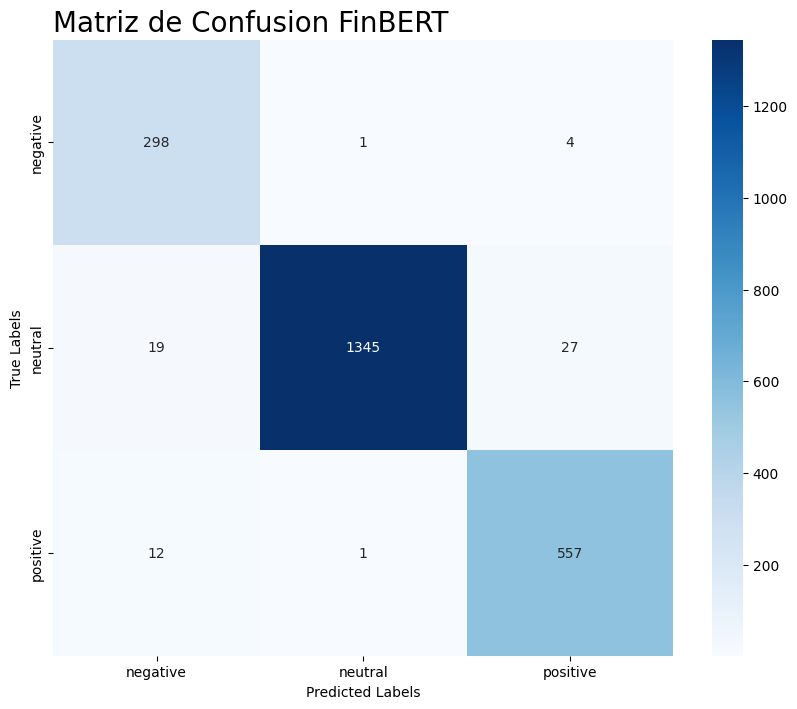

In [7]:
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_confusion, annot=True, fmt='d', cmap='Blues',
            xticklabels=[label_map[i] for i in range(len(label_map))],
            yticklabels=[label_map[i] for i in range(len(label_map))])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Matriz de Confusion FinBERT', fontsize=20, loc='left')
plt.show()